In [13]:
import sys, os
_base = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(_base, 'kepler-mapper'))
sys.path.insert(0, os.path.join(_base, 'mealpy'))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from smapper_utils import run_optimization, draw_graph, SEED, EPOCH, POP_SIZE

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import kmapper as km
import kmapper.evaluate as evaluate
from sklearn.neighbors import KernelDensity
from sklearn.cluster import AgglomerativeClustering
from collections import Counter

In [15]:
def r_style_scale(df):
    n = len(df)
    return df / np.sqrt((df ** 2).sum() / (n - 1))

data     = pd.read_csv('chemdiab.csv')
X        = data.iloc[:, :5].astype(float)
X_scaled = r_style_scale(X).to_numpy()
labels   = data['cc'].values

kde = KernelDensity(kernel='gaussian', bandwidth=1.0)
kde.fit(X_scaled)
projected_data = np.exp(kde.score_samples(X_scaled))

clusterer = AgglomerativeClustering(n_clusters=3, linkage='single')
mapper    = km.KeplerMapper(verbose=0)

In [25]:
def objective_function(X):
    n = int(round(float(X[0])))
    a = float(X[1])
    try:
        cover = km.Cover(n_cubes=n, perc_overlap=a)
        graph = mapper.map(projected_data, X_scaled, clusterer=clusterer, cover=cover)
        tsc   = evaluate.compute_SC_adj(X_scaled, projected_data, graph, cover,
                                         type='k', cluster=clusterer)
        return -tsc
    except Exception:
        return 3.0

from mealpy import FloatVar
problem = {
    'obj_func': objective_function,
    'bounds': [FloatVar(lb=5, ub=25, name='n'), FloatVar(lb=0.1, ub=0.7, name='a')],
    'minmax': 'min',
}
results = run_optimization(problem, 'results_output_diabetes.txt')

100%|██████████| 100/100 [00:00<00:00, 267.25it/s]
2026/05/06 09:49:11 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: Solving single objective optimization problem.


SC:-0.2684624969250994
SC_norm:0.3657687515374503
TSR:0.023809523809523808
SC_adj:0.19478913767348704


100%|██████████| 100/100 [00:00<00:00, 273.33it/s]


SC:-0.1364006429983853
SC_norm:0.43179967850080736
TSR:0.09523809523809523
SC_adj:0.2635188868694513


100%|██████████| 100/100 [00:00<00:00, 234.04it/s]


...

SC:0.011349698363445
SC_norm:0.5056748491817225
TSR:0.2857142857142857
SC_adj:0.3956945674480041


100%|██████████| 100/100 [00:00<00:00, 768.67it/s]


SC:0.011349698363445
SC_norm:0.5056748491817225
TSR:0.2857142857142857
SC_adj:0.3956945674480041


100%|██████████| 100/100 [00:00<00:00, 773.92it/s]
2026/05/06 09:51:44 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 20, Current best: -0.3956945674480041, Global best: -0.3956945674480041, Runtime: 2.69170 seconds


SC:0.011349698363445
SC_norm:0.5056748491817225
TSR:0.2857142857142857
SC_adj:0.3956945674480041


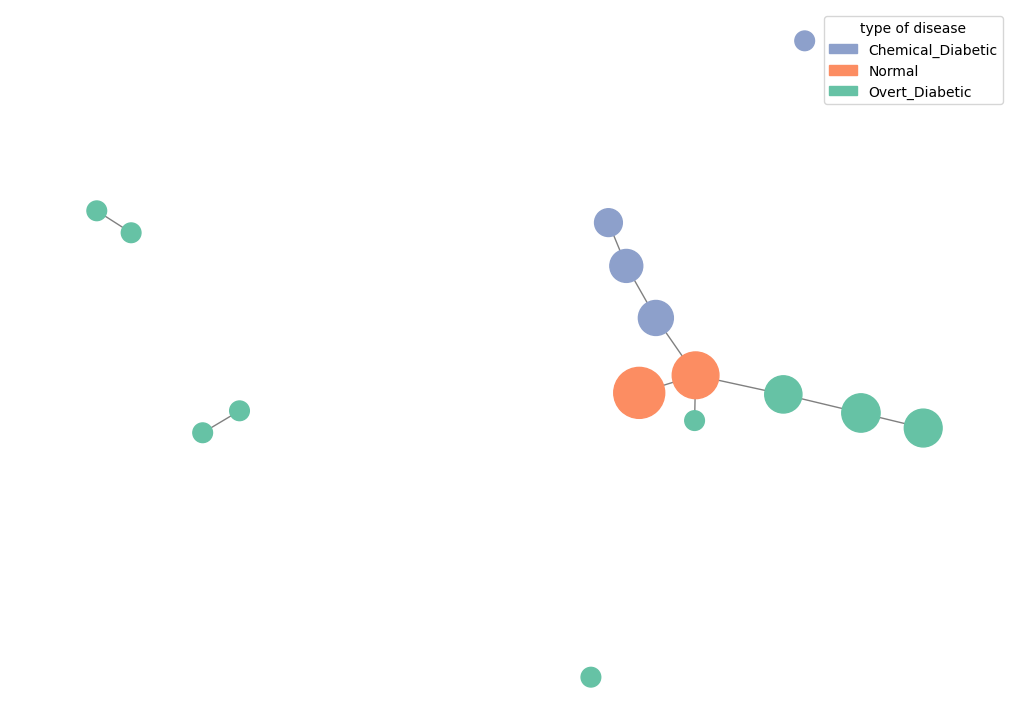

100%|██████████| 100/100 [00:00<00:00, 672.33it/s]

SC:-0.017208398623979
SC_norm:0.4913958006880105
TSR:0.2857142857142857
SC_adj:0.3885550432011481


0.3885550432011481

In [17]:
fixed_color_map = {
    'Normal':            '#fc8d62',
    'Chemical_Diabetic': '#8da0cb',
    'Overt_Diabetic':    '#66c2a5',
}

def mode(lst):
    return Counter(lst).most_common(1)[0][0]

def draw_diabetes_graph(graph, projected_data, labels, fixed_color_map, output_path=None):
    G = km.adapter.to_networkx(graph)
    node_colors = [fixed_color_map[mode(labels[list(graph['nodes'][v])])] for v in G.nodes]
    node_sizes  = [np.log2(len(graph['nodes'][v]) + 1) * 200 for v in G.nodes]
    plt.figure(figsize=(10, 7))
    nx.draw(G, node_color=node_colors, node_size=node_sizes, edge_color='gray', with_labels=False)
    patches = [mpatches.Patch(color=fixed_color_map[l], label=l) for l in sorted(fixed_color_map)]
    plt.legend(handles=patches, title='type of disease')
    if output_path:
        plt.savefig(output_path, bbox_inches='tight')
    plt.show()

n, a  = 5, 0.491
cover = km.Cover(n_cubes=n, perc_overlap=a)
graph = mapper.map(projected_data, X_scaled, clusterer=clusterer, cover=cover)
draw_diabetes_graph(graph, projected_data, labels, fixed_color_map, 'diabetes_mapper.png')
evaluate.compute_SC_adj(X_scaled, projected_data, graph, cover, type='k', cluster=clusterer)

# Mapper

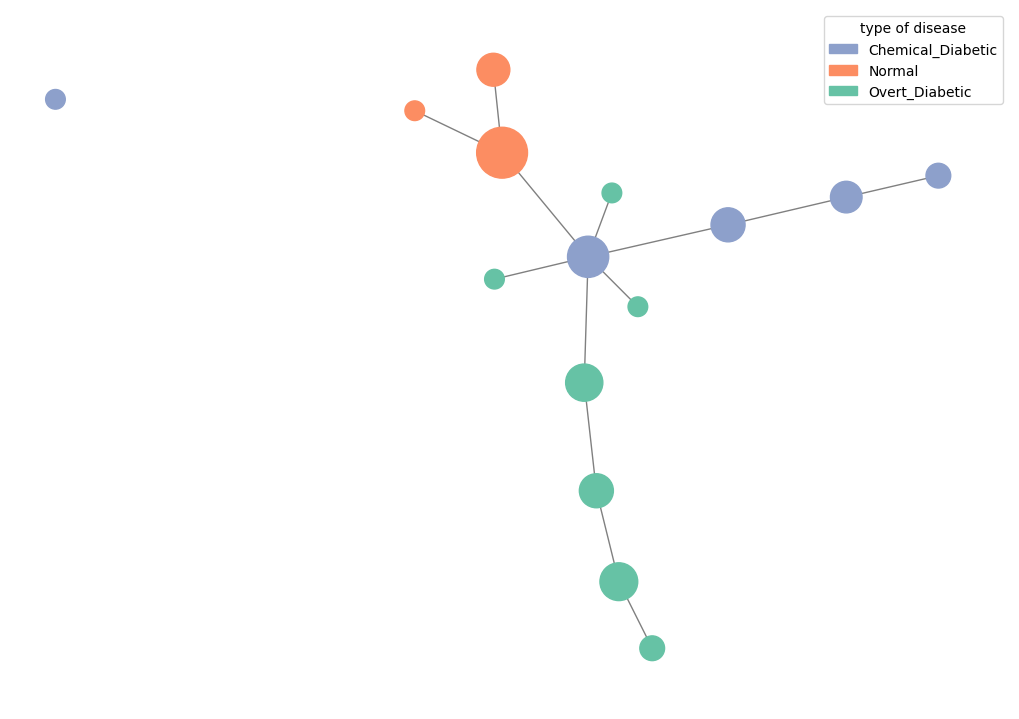

100%|██████████| 100/100 [00:00<00:00, 682.97it/s]

SC:-0.082607931578053
SC_norm:0.4586960342109735
TSR:0.2222222222222222
SC_adj:0.34045912821659785


0.34045912821659785

In [21]:
fixed_color_map = {
    'Normal':            '#fc8d62',
    'Chemical_Diabetic': '#8da0cb',
    'Overt_Diabetic':    '#66c2a5',
}

def mode(lst):
    return Counter(lst).most_common(1)[0][0]

def draw_diabetes_graph(graph, projected_data, labels, fixed_color_map, output_path=None):
    G = km.adapter.to_networkx(graph)
    node_colors = [fixed_color_map[mode(labels[list(graph['nodes'][v])])] for v in G.nodes]
    node_sizes  = [np.log2(len(graph['nodes'][v]) + 1) * 200 for v in G.nodes]
    plt.figure(figsize=(10, 7))
    nx.draw(G, node_color=node_colors, node_size=node_sizes, edge_color='gray', with_labels=False)
    patches = [mpatches.Patch(color=fixed_color_map[l], label=l) for l in sorted(fixed_color_map)]
    plt.legend(handles=patches, title='type of disease')
    if output_path:
        plt.savefig(output_path, bbox_inches='tight')
    plt.show()

n, a  = 5, 0.3
cover = km.Cover(n_cubes=n, perc_overlap=a)
graph = mapper.map(projected_data, X_scaled, clusterer=clusterer, cover=cover)
draw_diabetes_graph(graph, projected_data, labels, fixed_color_map, 'diabetes_mapper.png')
evaluate.compute_SC_adj(X_scaled, projected_data, graph, cover, type='k', cluster=clusterer)

# D-Mapper

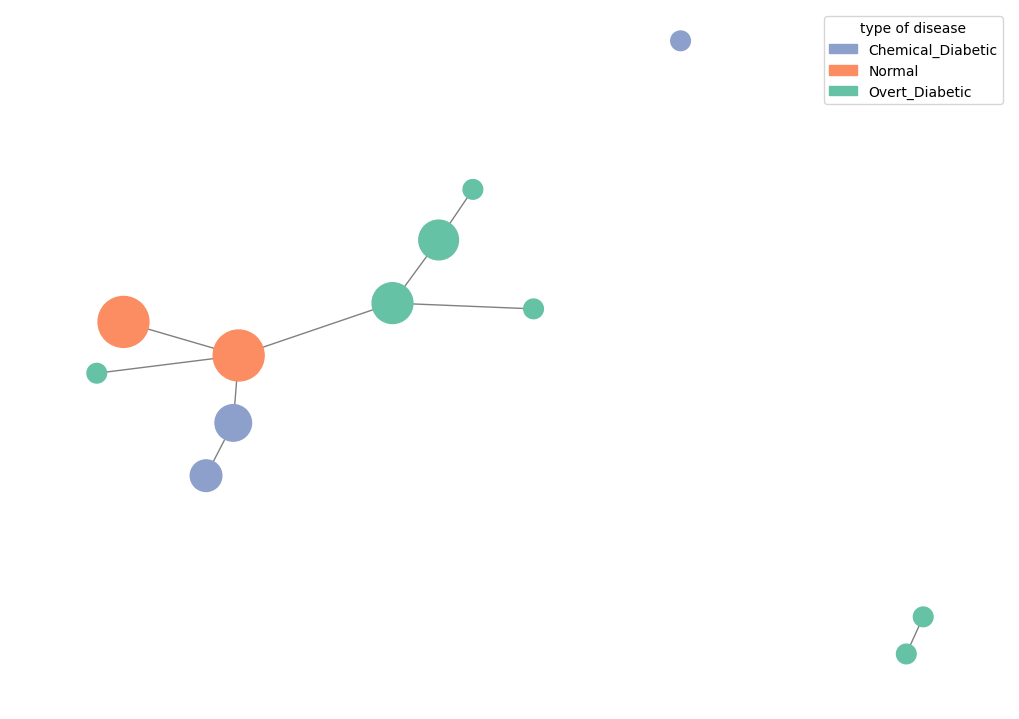

100%|██████████| 100/100 [00:01<00:00, 68.05it/s]

SC:-0.09120523377
SC_norm:0.454397383115
TSR:0.14285714285714285
SC_adj:0.29862726298607145


0.29862726298607145

In [22]:

dmapper = km.D_Mapper(verbose=0)
n, a    = 4, 0.4
cover_d = km.D_Cover(n_cubes=n, alpha=a, max_iter=100000, n_init=10, verbose=0)
graphD  = dmapper.map(projected_data, X_scaled, clusterer=clusterer, cover=cover_d)
draw_diabetes_graph(graphD, projected_data, labels, fixed_color_map, 'diabetes_dmapper.png')
evaluate.compute_SC_adj(X_scaled, projected_data, graphD,
                         km.D_Cover(n_cubes=n, alpha=a, verbose=0),
                         type='d', cluster=clusterer)